In [1]:
!pip install -q torch torchvision
!pip install -q triton einops tqdm

!git clone -q https://github.com/ming053l/ELSA.git
%cd ELSA
!pip install -q -e ".[benchmark]"

fatal: destination path 'ELSA' already exists and is not an empty directory.
/content/ELSA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for elsa-twopass-clean (pyproject.toml) ... done


In [2]:
import sys
sys.path.append('/content/ELSA/code/stable')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

ELSA_AVAILABLE = False
try:
    from elsa_triton import ELSA_triton_fp32
    ELSA_AVAILABLE = True
except:
    pass

Device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

from torch.utils.data import Subset
train_idx = np.random.choice(len(train_dataset), 3000, replace=False)
test_idx = np.random.choice(len(test_dataset), 500, replace=False)

train_subset = Subset(train_dataset, train_idx)
test_subset = Subset(test_dataset, test_idx)

batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_subset)}, Test: {len(test_subset)}")
print(f"Classes: {train_dataset.classes}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.0MB/s]

Train: 3000, Test: 500
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


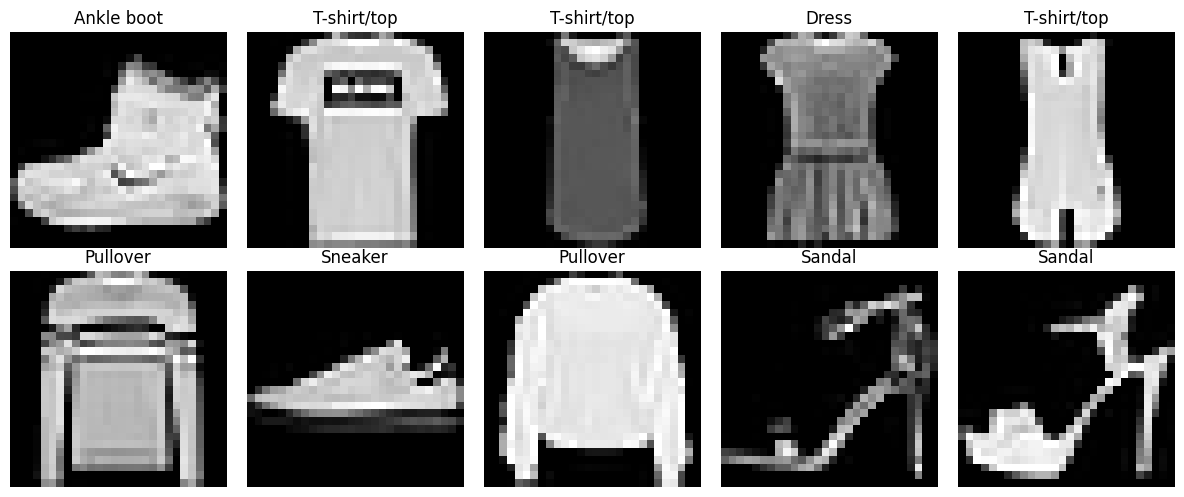

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_dataset.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
class StandardAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(out)


class LinearAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0
        kv = k.transpose(-2, -1) @ v
        out = (q @ kv) / (q @ k.sum(dim=-2, keepdim=True).transpose(-2, -1) + 1e-6)
        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj(out)


class ELSAAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        if ELSA_AVAILABLE and device.type == 'cuda':
            out = ELSA_triton_fp32.apply(q, k, v, self.scale)
        else:
            q = F.elu(q) + 1.0
            k = F.elu(k) + 1.0
            kv = k.transpose(-2, -1) @ v
            out = (q @ kv) / (q @ k.sum(dim=-2, keepdim=True).transpose(-2, -1) + 1e-6)
        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

In [6]:
class ImageTransformer(nn.Module):
    def __init__(self, attn_type='standard', img_size=28, patch_size=7,
                 embed_dim=128, num_heads=4, num_layers=3, num_classes=10):
        super().__init__()

        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) ** 2

        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        self.blocks = nn.ModuleList()
        for _ in range(num_layers):
            if attn_type == 'standard':
                attn = StandardAttention(embed_dim, num_heads)
            elif attn_type == 'linear':
                attn = LinearAttention(embed_dim, num_heads)
            else:
                attn = ELSAAttention(embed_dim, num_heads)

            block = nn.ModuleDict({
                'attn': attn,
                'norm1': nn.LayerNorm(embed_dim),
                'norm2': nn.LayerNorm(embed_dim),
                'ffn': nn.Sequential(
                    nn.Linear(embed_dim, embed_dim * 4),
                    nn.GELU(),
                    nn.Linear(embed_dim * 4, embed_dim),
                    nn.Dropout(0.1)
                )
            })
            self.blocks.append(block)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embed

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        for block in self.blocks:
            x = x + block['attn'](block['norm1'](x))
            x = x + block['ffn'](block['norm2'](x))

        x = self.norm(x)
        return self.head(x[:, 0])


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [7]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in tqdm(loader, desc='Training', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
    return total_loss / len(loader), 100. * correct / total

In [8]:
def run_experiment(attn_type, train_loader, test_loader, epochs=10):
    print(f"Эксперимент: {attn_type.upper()}")

    model = ImageTransformer(
        attn_type=attn_type,
        img_size=28,
        patch_size=7,
        embed_dim=128,
        num_heads=4,
        num_layers=3
    ).to(device)

    params = count_params(model)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_acc': [], 'test_acc': [], 'times': []}

    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        epoch_time = time.time() - start

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['times'].append(epoch_time)

        print(f"Epoch {epoch:2d}/{epochs} | Train: {train_acc:5.2f}% | Test: {test_acc:5.2f}% | Time: {epoch_time:.1f}s")

    model.eval()
    times = []
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            start = time.time()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.time() - start)
    inf_time = np.mean(times) * 1000

    return model, history, {'inf_time': inf_time, 'best_acc': max(history['test_acc'])}

In [9]:
attention_types = ['standard', 'linear', 'elsa']

results = {}
histories = {}

for attn_type in attention_types:
    model, history, metrics = run_experiment(attn_type, train_loader, test_loader, epochs=10)
    results[attn_type] = metrics
    histories[attn_type] = history
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

Эксперимент: STANDARD


Epoch  1/10 | Train: 49.07% | Test: 62.40% | Time: 4.9s


Epoch  2/10 | Train: 69.67% | Test: 69.60% | Time: 5.4s


Epoch  3/10 | Train: 75.60% | Test: 74.60% | Time: 5.0s


Epoch  4/10 | Train: 78.73% | Test: 74.40% | Time: 5.3s


...

Epoch  6/10 | Train: 80.07% | Test: 72.60% | Time: 5.4s


Epoch  7/10 | Train: 81.43% | Test: 75.40% | Time: 5.7s


Epoch  8/10 | Train: 83.43% | Test: 78.40% | Time: 5.3s


Epoch  9/10 | Train: 85.07% | Test: 77.80% | Time: 5.8s


Epoch 10/10 | Train: 86.57% | Test: 78.00% | Time: 5.4s


In [10]:
print(f"{'Механизм':<12} {'Accuracy':<14} {'Inference (ms)':<18} {'Params':<12}")


for attn_type in attention_types:
    m = results[attn_type]
    params = count_params(ImageTransformer(attn_type=attn_type))
    print(f"{attn_type:<12} {m['best_acc']:<14.2f}% {m['inf_time']:<18.2f} {params:<12,}")

Механизм     Accuracy       Inference (ms)     Params      
standard     81.60         % 17.16              604,938     
linear       77.60         % 12.62              604,938     
elsa         78.40         % 13.03              604,938     


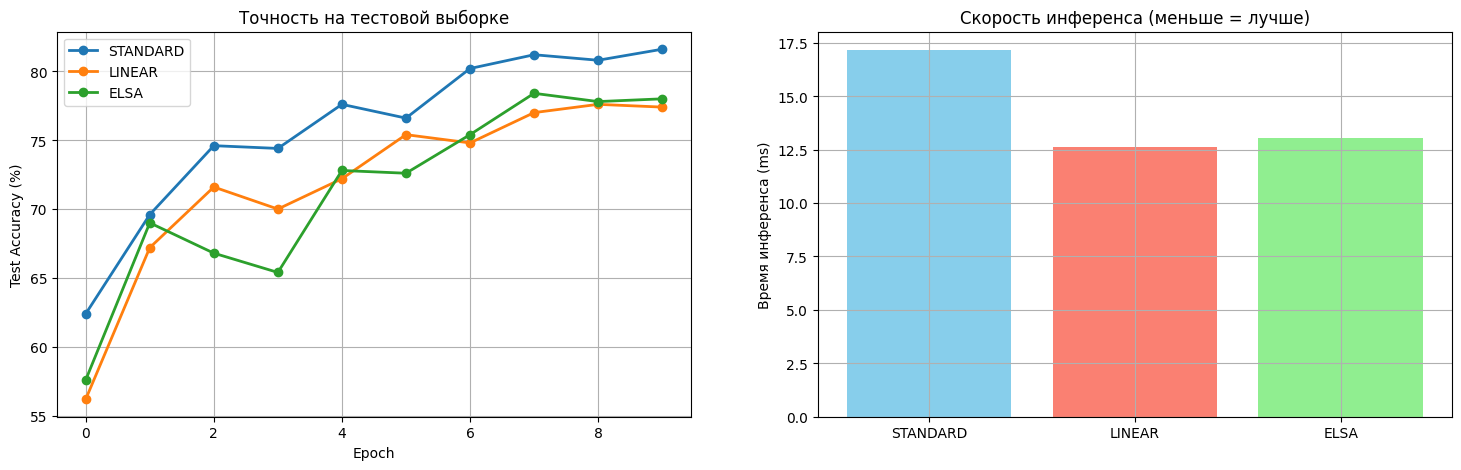

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax = axes[0]
for attn_type in attention_types:
    ax.plot(histories[attn_type]['test_acc'], marker='o', label=attn_type.upper(), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Точность на тестовой выборке')
ax.legend()
ax.grid(True)

ax = axes[1]
x = np.arange(len(attention_types))
inf = [results[t]['inf_time'] for t in attention_types]
labels = [t.upper() for t in attention_types]

colors = ['skyblue', 'salmon', 'lightgreen']
ax.bar(x, inf, color=colors[:len(attention_types)])
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Время инференса (ms)')
ax.set_title('Скорость инференса (меньше = лучше)')
ax.grid(True)

Наилучшая точность достигнута механизмом Standard Attention (81.60%).

Линейная и ELSA версии показали близкую точность (~77–78%), уступая стандартной, но значительно превосходя её по скорости инференса.

Быстрее всего работает Linear Attention (12.62 мс), что делает его предпочтительным при необходимости высокой производительности.

ELSA занимает промежуточное положение: чуть медленнее Linear, но точнее его, и почти догоняет Standard по качеству при заметном выигрыше в скорости.